# Mask & Crop

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on masking and croping a raster object.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [1]:
import numpy as np

import geopandas as gpd

import rasterio
import rasterio.mask
from rasterio.plot import show

import rioxarray

import odc.geo.xr
from odc.geo.xr import mask
from odc.geo.xr import crop
from odc.geo import Geometry

import geoutils as gu

import matplotlib.pyplot as plt

import dask

import fiona
from shapely.geometry import shape

In [2]:
#path to the raster object
raster_path = "../data/PlanetObserver_PlanetSAT_10m_Ukraine_Odessa_UTM36.tif"

In [3]:
#path to the vector object
vector_path = "../data/odessa_extent.shp"

## Masking (with a vector)

Masking with a vector is a feature available in rasterio, rioxarray and odc-geo librairies, but not (yet) in geoutils.

A vector mask allows to isolate a specific area of interest according to the shape of the mask.

In this example we will work with a polygon (.shp) focusing on the city of Odessa (Ukraine).

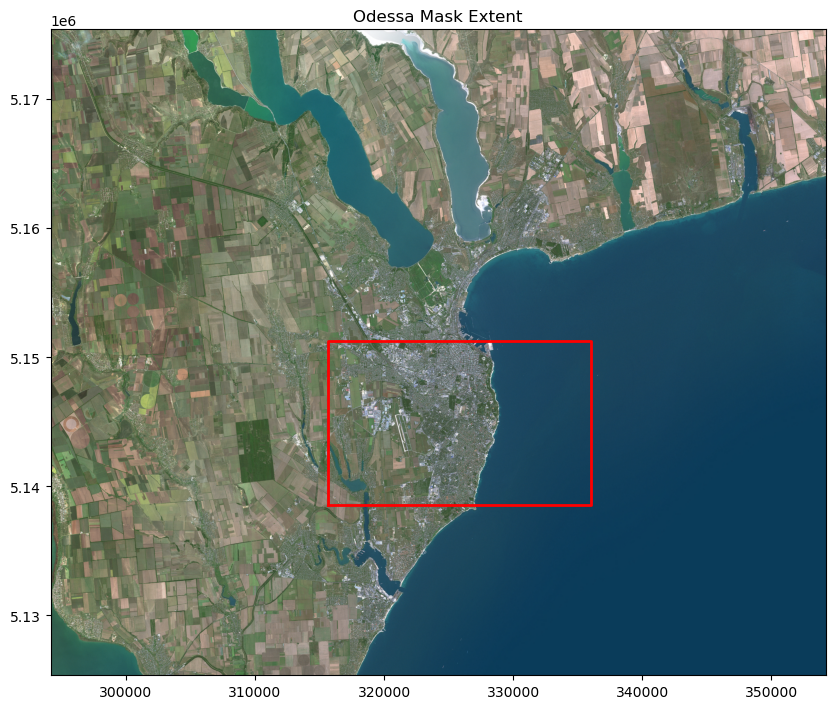

In [4]:
with rasterio.open(raster_path) as src:
    fig, ax = plt.subplots(figsize=(10, 10))

    show(src, ax=ax)

with fiona.open(vector_path) as v:
    for feature in v:
        geom = shape(feature["geometry"])
        xs, ys = geom.exterior.xy
        ax.plot(xs, ys, color="red", linewidth=2)

plt.title("Odessa Mask Extent")
plt.show()

### • rasterio

First, we can create our vector shape to be used as a mask using the fiona library :

In [5]:
with fiona.open(vector_path, "r") as shp:
    shape = [feature["geometry"] for feature in shp]

With rasterio, we can then use the *.mask()* function : https://rasterio.readthedocs.io/en/latest/api/rasterio.mask.html

Here we specify "crop=False" to not crop to the extent of the shape.

In [6]:
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, shape, crop=False)

If we plot the result :

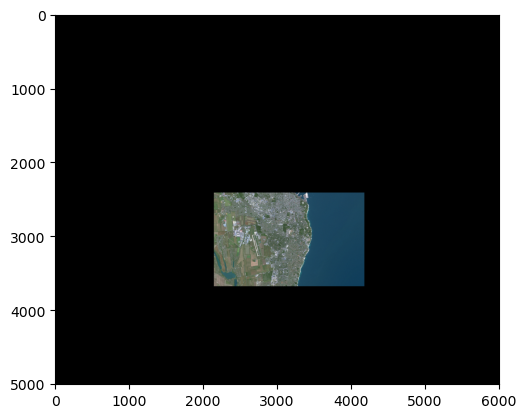

<Axes: >

In [7]:
show(out_image)

### • rioxarray

In rioxarray, we can use the *.clip()* function : https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.clip

Once again, we specify "drop=False" (as "crop=False" for rasterio) to not crop to the extent of the shape.

In [8]:
da_rxr = rioxarray.open_rasterio(raster_path)

da_clipped = da_rxr.rio.clip(shape, drop=False)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\xarray\core\duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


We can plot the result :

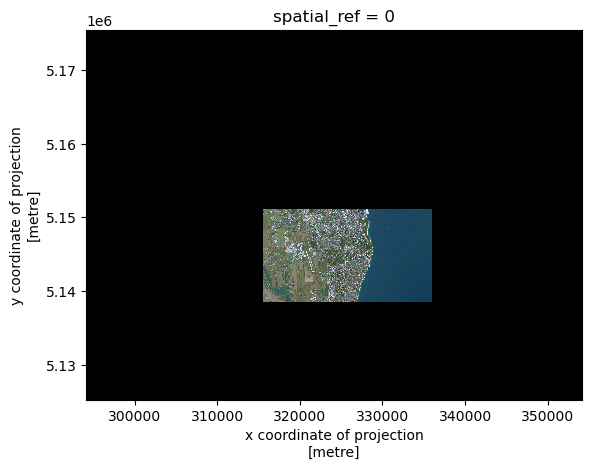

In [9]:
da_clipped.plot.imshow()
plt.show()

### • odc-geo

In odc-geo, we will use the *.mask()* function : https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.mask.html

In [10]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

First, we need to create an object odc.geo.geom.Geometry to be used as a mask :

In [11]:
g = Geometry(geom, crs="EPSG:32636") #we specify the CRS

And then we can use our vector with the mask function :

In [12]:
odcgeo_clipped = ds_odcgeo.odc.mask(g, invert=False)

In [13]:
odcgeo_clipped

<xarray.DataArray (band: 3, y: 5003, x: 6003)> Size: 360MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(3, 5003, 6003), dtype=float32)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 48kB 2.942e+05 2.942e+05 ... 3.542e+05 3.542e+05
  * y            (y) float64 40kB 5.175e+06 5.175e+06 ... 5.125e+06 5.125e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        255
    STATISTICS_MEAN:           84.532974253614
    STATISTICS_MINIMUM:        4
    STATISTICS_STDDEV:         57.209552559308
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

We can finally plot the result :

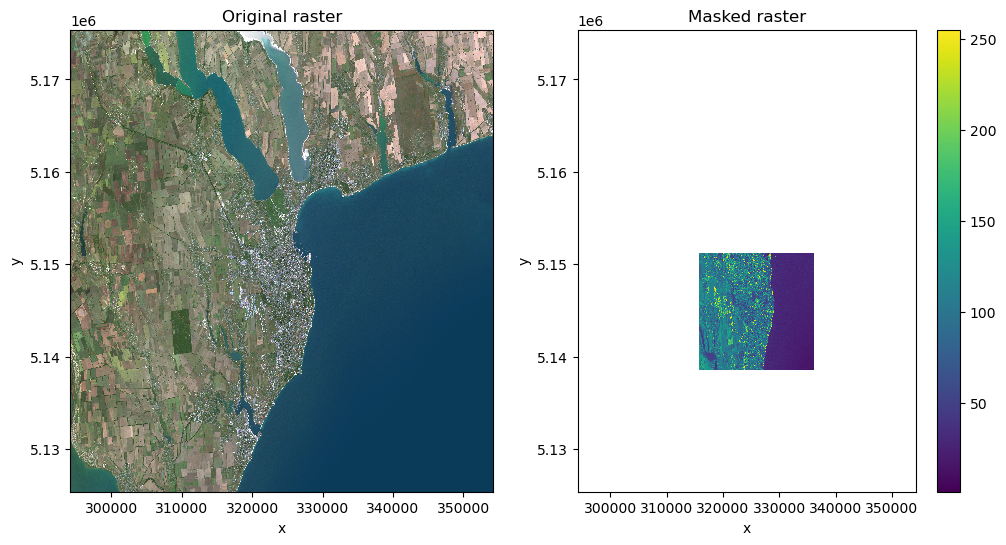

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ds_odcgeo.plot.imshow(ax=ax[0])
ax[0].set_title("Original raster")

odcgeo_clipped.sel(band=1).plot.imshow(ax=ax[1])
ax[1].set_title("Masked raster")

plt.show()

### • geoutils

https://github.com/GlacioHack/geoutils/issues/583

==TO BE COMPLETED==

## Crop

Cropping feature is available in rasterio, rioxarray, odc-geo and geoutils.

This method is used to delete all pixels outside of a specified area.

### • rasterio

To use this feature in rasterio, we can reuse the *.mask()* function.

This time, we will pass the argument "crop=True" so we do not keep the pixels outside our area. 

In [15]:
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, shape, crop=True)

If we plot the image, borders have been erased :

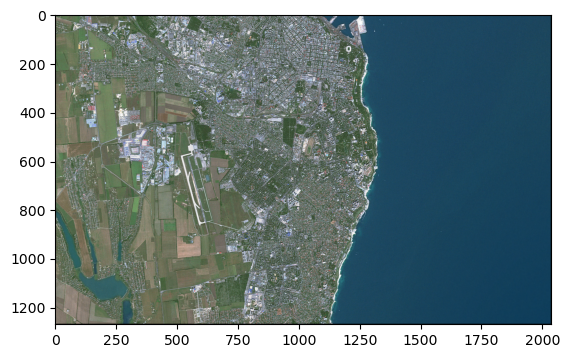

<Axes: >

In [16]:
show(out_image)

### • rioxarray

In rioxarray, we can use the *.clip_box()* function : https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.clip_box

In [17]:
da_rxr = rioxarray.open_rasterio(raster_path)

To use this function, we need to get the bounds of our polygon :

In [18]:
minx, miny, maxx, maxy = geom.bounds

Then, we can apply the *clip_box()* function.

We need to specify the bounds of the box we want to use :

In [19]:
rxr_cropped = da_rxr.rio.clip_box(minx=minx,miny=miny,maxx=maxx,maxy=maxy)

Finally, we can plot the image :

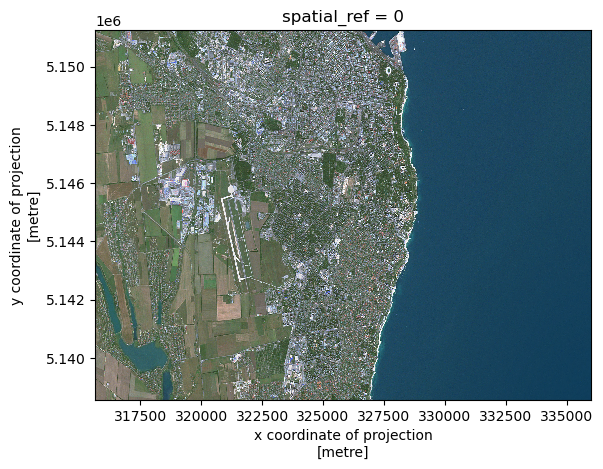

In [20]:
rxr_cropped.plot.imshow()

### • odc-geo

For odc-geo, we will use the *.crop()* function : https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.crop.html#odc.geo.xr.crop

In [21]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

We pass the geometry previously created as an argument :

In [22]:
odcgeo_cropped = ds_odcgeo.odc.crop(g)

In [23]:
odcgeo_cropped

<xarray.DataArray (band: 3, y: 1269, x: 2037)> Size: 31MB
array([[[148., 140., 113., ...,  34.,  28.,  28.],
        [132., 127.,  95., ...,  24.,  31.,  29.],
        [122., 110.,  88., ...,  25.,  27.,  28.],
        ...,
        [138., 150., 157., ...,  15.,  15.,  15.],
        [144., 155., 166., ...,  15.,  15.,  16.],
        [152., 159., 163., ...,  15.,  15.,  16.]],

       [[138., 136., 121., ...,  79.,  70.,  67.],
        [126., 129., 107., ...,  67.,  73.,  69.],
        [122., 117., 104., ...,  69.,  71.,  71.],
        ...,
        [129., 147., 151., ...,  62.,  62.,  62.],
        [130., 141., 153., ...,  62.,  62.,  62.],
        [135., 138., 145., ...,  62.,  62.,  62.]],

       [[118., 114., 104., ..., 109.,  97.,  92.],
        [104., 103.,  83., ..., 103., 102.,  92.],
        [100.,  88.,  75., ...,  98.,  97.,  94.],
        ...,
        [117., 135., 143., ...,  91.,  91.,  91.],
        [112., 133., 149., ...,  90.,  90.,  90.],
        [115., 131., 143., ...,  90.,  90.,  90.]]],
      shape=(3, 1269, 2037), dtype=float32)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 16kB 3.157e+05 3.157e+05 ... 3.36e+05 3.36e+05
  * y            (y) float64 10kB 5.151e+06 5.151e+06 ... 5.139e+06 5.139e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        255
    STATISTICS_MEAN:           84.532974253614
    STATISTICS_MINIMUM:        4
    STATISTICS_STDDEV:         57.209552559308
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

We can plot the image :

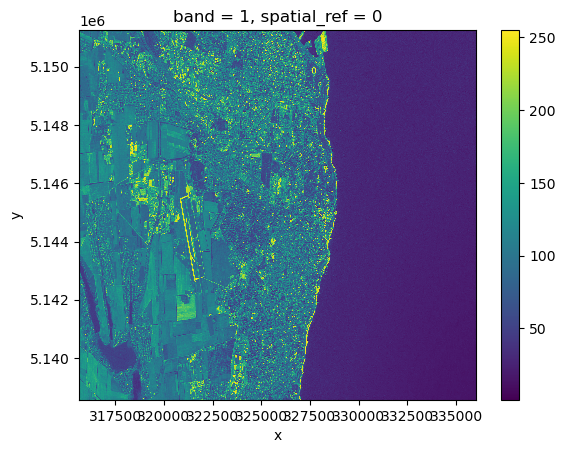

In [24]:
odcgeo_cropped.sel(band=1).plot.imshow()

### • geoutils

For geoutils, we will directly use the *.crop()* function : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.crop.html#geoutils.Raster.crop

In [25]:
gu_rast = gu.Raster(raster_path)

gu_vect = gu.Vector(vector_path)

In [26]:
print(gu_vect.bounds)

BoundingBox(left=np.float64(315655.7030071), bottom=np.float64(5138573.914418323), right=np.float64(336012.14445399627), top=np.float64(5151252.049003671))


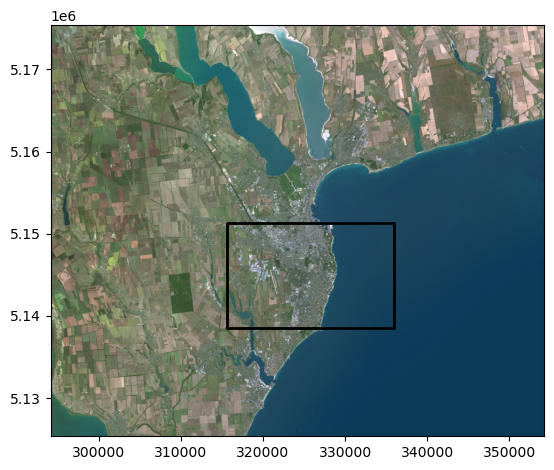

In [27]:
gu_rast.plot()
gu_vect.plot(fc="none", ec="k", lw=2)

Then, we can use the *.crop* function :

In [28]:
gu_cropped = gu_rast.crop(gu_vect)

We can plot the newly cropped raster :

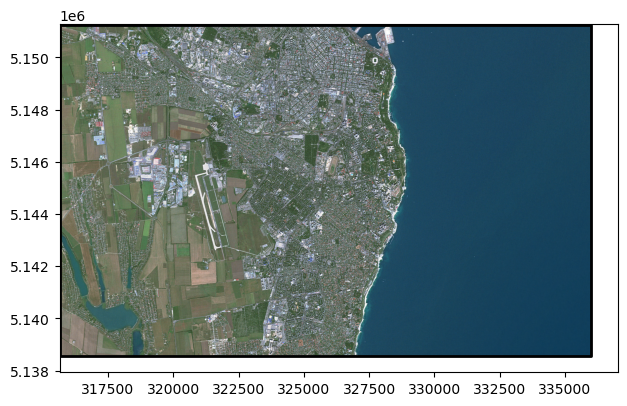

In [29]:
gu_cropped.plot(ax="new")
gu_vect.plot(fc="none", ec="k", lw=2)